# Desarrollo de modelos de Regresión Lineal Múltiple y diagnóstico de colinealidad mediante el Factor de Inflación de la Varianza (VIF).-Grupo A

#Tarea 1

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# 1. Generación de datos simulados multivariados
np.random.seed(42)
n_muestras = 150
lineas_codigo = np.random.randint(5000, 50000, size=n_muestras) # X1
ram_disponible = np.random.uniform(4.0, 32.0, size=n_muestras) # X2

# Y = B0 + B1*X1 + B2*X2 + Error
# A más líneas, más tiempo (+). A más RAM, menos tiempo (-)
tiempo_compilacion = 15.0 + (0.002 * lineas_codigo) - (1.5 * ram_disponible) + np.random.normal(0, 15, size=n_muestras)
df_simulado = pd.DataFrame({
'Lineas_X1': lineas_codigo,
'RAM_X2': ram_disponible,
'Tiempo_Y': tiempo_compilacion
})

# 2. Configuración de la matriz de características X y el vector Y
X_multi = df_simulado[['Lineas_X1', 'RAM_X2']]
Y_multi = df_simulado['Tiempo_Y']
# Añadir la constante (Intercepto B0)
X_multi_sm = sm.add_constant(X_multi)

# 3. Ajuste del Modelo OLS Múltiple
modelo_multiple = sm.OLS(Y_multi, X_multi_sm).fit()
# Imprimir el resumen estadístico
print(modelo_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:               Tiempo_Y   R-squared:                       0.791
Model:                            OLS   Adj. R-squared:                  0.788
Method:                 Least Squares   F-statistic:                     278.4
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           1.02e-50
Time:                        03:02:15   Log-Likelihood:                -617.66
No. Observations:                 150   AIC:                             1241.
Df Residuals:                     147   BIC:                             1250.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         21.1081      3.866      5.459      0.0

#Tarea 2

In [ ]:
import pandas as pd
import statsmodels.api as sm

nombres_col = ["Fecha", "Tipo", "Emisor", "Cantidad", "Val_Nom", "Precio",
               "VNT", "Monto_Efectivo", "CO", "CD", "Bolsa"]

try:
    df = pd.read_csv("BVG_Acciones_export.csv", names=nombres_col, skiprows=1)

    # Variable Respuesta (Y): Monto_Efectivo (Capital total de la transacción)
    # Variables Predictoras (X): Cantidad (Volumen) y Precio (Valor unitario)

    cols_interes = ['Monto_Efectivo', 'Cantidad', 'Precio']
    for col in cols_interes:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df_clean = df.dropna(subset=cols_interes)

    # Entrenamiento del modelo OLS Múltiple
    Y = df_clean['Monto_Efectivo']
    X = df_clean[['Cantidad', 'Precio']]
    X = sm.add_constant(X)

    modelo_multiple = sm.OLS(Y, X).fit()

    # Impresión del resumen estadístico
    print(modelo_multiple.summary())

except FileNotFoundError:
    print("Error: Asegúrese de que 'BVG_Acciones_export.csv' esté en el directorio.")


                            OLS Regression Results                            
Dep. Variable:         Monto_Efectivo   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.824
Method:                 Least Squares   F-statistic:                 6.841e+04
Date:                Mon, 20 Jul 2026   Prob (F-statistic):               0.00
Time:                        03:07:36   Log-Likelihood:            -3.5653e+05
No. Observations:               29131   AIC:                         7.131e+05
Df Residuals:                   29128   BIC:                         7.131e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6345.9060    298.141     21.285      0.0

### Los coeficientes representan el cambio esperado en el Monto Efectivo por cada unidad de cambio en una variable predictora, manteniendo la otra constante. B1 indica cuanto aumenta el capital movilizado por acción adicional realizada. B2 representa el impacto del valor de mercado de la acción sobre el monto total.
### El estadístico t dice cuantas desviaciones estándar está el coeficiente de cero, un valor más alto implica mayor impacto. Cantidad tiene un estadístico t mayor que el estadístico t de Precio. Entonces Cantidad tiene un impacto mayor en el Monto_Efectivo dentro del modelo. Aun así, ambas variables son significativas.
### El valor P>|t| es cero tanto para Cantidad como para Precio. Ambas variables son estadísticamente significativas y ayudan al modelo a predecir el Monto_Efectivo.

#Tarea 3

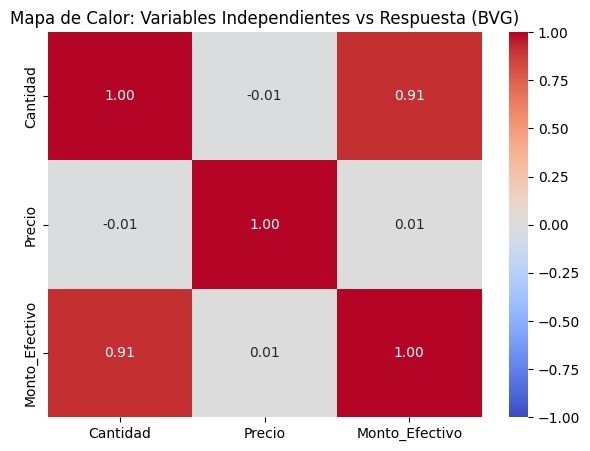

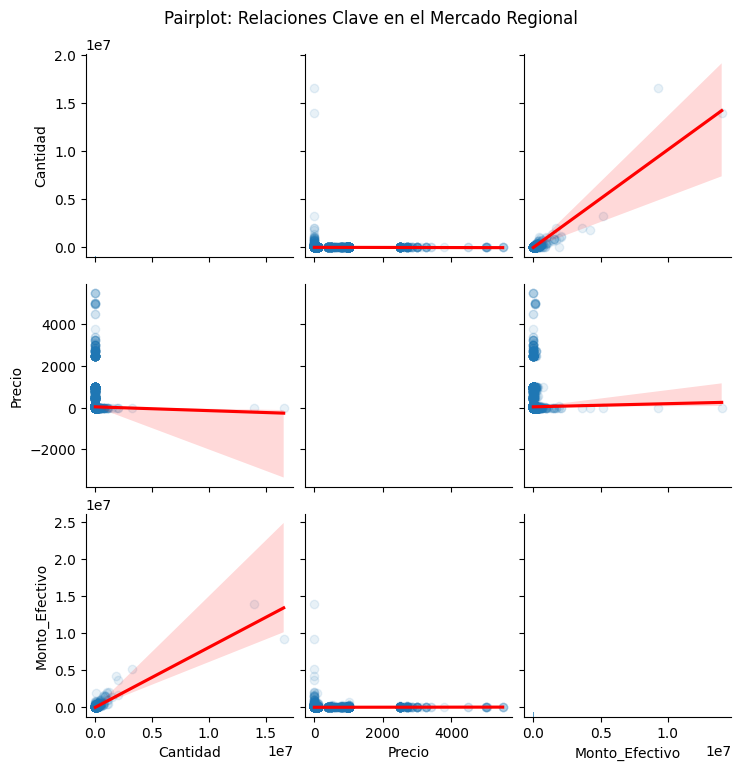

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configuración de nombres de columnas según el dataset BVG [Source 1]
nombres_col = ["Fecha", "Tipo", "Emisor", "Cantidad", "Val_Nom", "Precio",
               "VNT", "Monto_Efectivo", "CO", "CD", "Bolsa"]

df = pd.read_csv("BVG_Acciones_export.csv", names=nombres_col, skiprows=1)

# 2. Selección de variables esenciales: Predictoras (X) y Respuesta (Y)
# Se eliminan VNT y Val_Nom por redundancia estadística [Montgomery, 562]
columnas_optimas = ['Cantidad', 'Precio', 'Monto_Efectivo']

for col in columnas_optimas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Limpieza de nulos para asegurar la integridad de la matriz
df_bvg = df[columnas_optimas].dropna()

# 3. Matriz de Correlación
# Ahora enfocada en la relación entre Volumen, Precio y Capital Movilizado
matriz_corr = df_bvg.corr()

# 4. Visualización mediante Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Mapa de Calor: Variables Independientes vs Respuesta (BVG)')
plt.show()

# 5. Visualización de dispersiones múltiples (Pairplot)
# Muestra la relación lineal entre Cantidad y Monto_Efectivo sin ruido de VNT
sns.pairplot(df_bvg, kind='reg', plot_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha': 0.1}})
plt.suptitle('Pairplot: Relaciones Clave en el Mercado Regional', y=1.02)
plt.show()

### No hay una correlación alta entre cantidad y precio, son relativamente independientes entre sí, lo que permitirá al modelo de regresión lineal estimar sus coeficientes de manera más estable y confiable
### Hay una correlación alta y positiva de 0.907855, entre Monto_Efectivo y Cantidad. Esto indica que a medida que la Cantidad de acciones transaccionadas aumenta, el Monto_Efectivo también tiende a aumentar de manera fuerte y lineal.

###  Hay una correlación baja y positiva de 0.007562, entre Monto_Efectivo y Precio. Esto sugiere que la relación lineal entre el Precio y el Monto_Efectivo es prácticamente inexistente o muy débil en este conjunto de datos. Es la Cantidad la que domina la variabilidad de Monto_Efectivo en este contexto, lo cual se alinea con la alta correlación entre Cantidad y Monto_Efectivo.

#Tarea 4

In [11]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

nombres_col = ["Fecha", "Tipo", "Emisor", "Cantidad", "Val_Nom", "Precio",
               "VNT", "Monto_Efectivo", "CO", "CD", "Bolsa"]

df = pd.read_csv("BVG_Acciones_export.csv", names=nombres_col, skiprows=1)

columnas_x = ['Cantidad', 'Precio']

for col in columnas_x:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df_vif = df[columnas_x].dropna()

# Preparación de la matriz de predictores con constante
X_multi_sm = sm.add_constant(df_vif)

# Cálculo del VIF para cada variable independiente
vif_data = pd.DataFrame()
vif_data["Variable"] = X_multi_sm.columns
vif_data["VIF"] = [variance_inflation_factor(X_multi_sm.values, i)
                   for i in range(X_multi_sm.shape[1])]

vif_resultado = vif_data[vif_data["Variable"] != "const"]

print("\n--- ANÁLISIS DE MULTICOLINEALIDAD OPTIMIZADO (Dataset BVG) ---")
print(vif_resultado)

# Interpretación Técnica de los Resultados
print("\n--- Dictamen de Ingeniería ---")
for _, row in vif_resultado.iterrows():
    variable, vif = row["Variable"], row["VIF"]
    if vif < 5:
        print(f"{variable}: VIF={vif:.2f} → Independencia validada. Sin evidencia de multicolinealidad.")
    elif 5 <= vif < 10:
        print(f"{variable}: VIF={vif:.2f} → Precaución: Multicolinealidad moderada detectada.")
    else:
        print(f"{variable}: VIF={vif:.2f} → CRÍTICO: Multicolinealidad severa. Se debe eliminar esta variable.")



--- ANÁLISIS DE MULTICOLINEALIDAD OPTIMIZADO (Dataset BVG) ---
   Variable       VIF
1  Cantidad  1.000103
2    Precio  1.000103

--- Dictamen de Ingeniería ---
Cantidad: VIF=1.00 → Independencia validada. Sin evidencia de multicolinealidad.
Precio: VIF=1.00 → Independencia validada. Sin evidencia de multicolinealidad.


### El VIF nos dice cuánto se ha inflado la varianza de un coeficiente de regresión estimado debido a la colinealidad con otras variables predictoras en el modelo.
### Ambos valores de VIF son extremadamente cercanos a 1.00. Estos resultados indican:

### Que no hay evidencia de multicolinealidad entre Cantidad y Precio. Por lo que los coeficientes estimados para Cantidad y Precio en un modelo de regresión lineal múltiple serán estables y sus errores estándar no estarán inflados debido a la intercorrelación entre ellas. Podemos interpretar con confianza la contribución única de cada variable al Monto_Efectivo.